In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import mistsim.plotting as msplt
%matplotlib inline

d = np.load("/home/christian/Documents/research/MIST/mistsim/notebooks/mapmaking/results/mars-csa2022-dip-nv-dip-nv-mono-analytic.npz")
freqs = d["freqs"]
lmax = int(d["lmax"])
x_true = d["x_true"]
x_rec = d["x_rec"]
std_alm = d["std_alm"]
cl_prior = d["cl_prior"]
sigma2_prior = float(d["sigma2_prior"])
Sigma = d["Sigma"]
nvec = int(d["nvec"])
std_map = d["std_map"]


# Diagnostics: mars-csa2022-dip-nv-dip-nv-mono-analytic

**Sites:** mars-csa2022-dip, nv-dip, nv-mono-analytic  
**lmax:** 179  
**nvec:** 1053  
**SVD k:** 1200

## Singular Value Spectrum

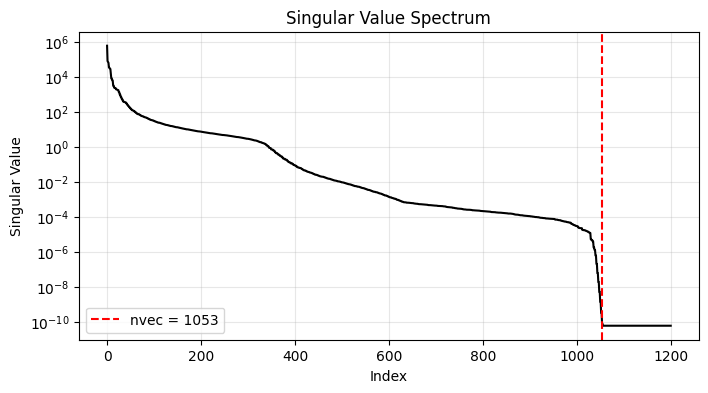

In [2]:
fig = msplt.plot_singular_values(Sigma, nvec=nvec)
plt.show()

## Filter Factors

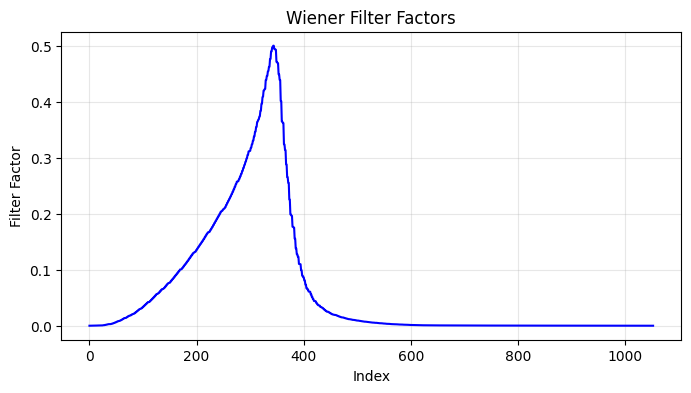

In [3]:
Dnum = Sigma[:nvec]
D = Dnum / (1 + Dnum**2)
fig = msplt.plot_filter_factors(D)
plt.show()

## Alm Comparison

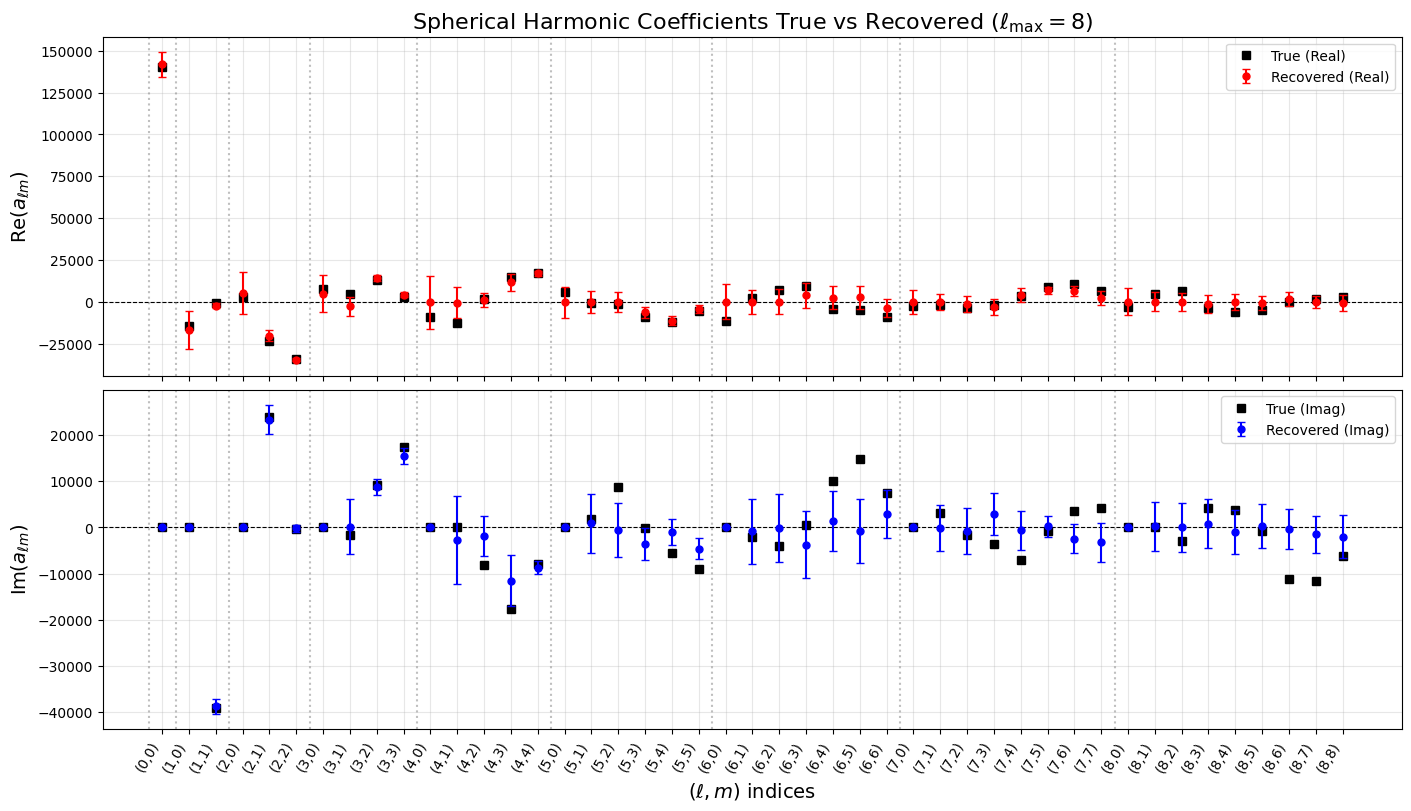

In [4]:
fig = msplt.plot_alm_comparison(
    x_true, x_rec, std_alm, lmax, lmax_plot=8
)
plt.show()

## Power Spectra

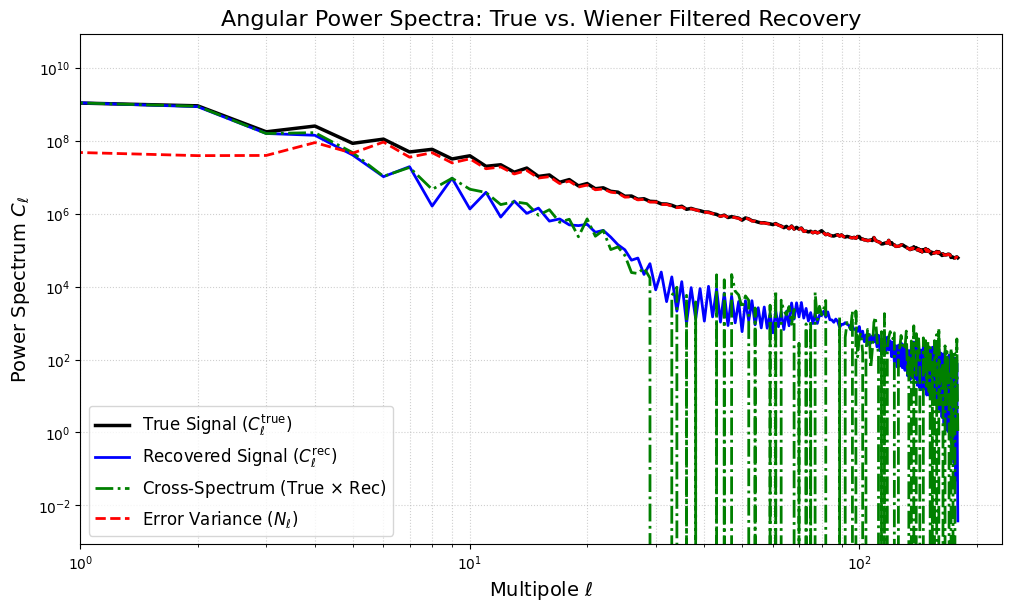

In [5]:
fig = msplt.plot_power_spectra(x_true, x_rec, std_alm)
plt.show()

## Transfer Function

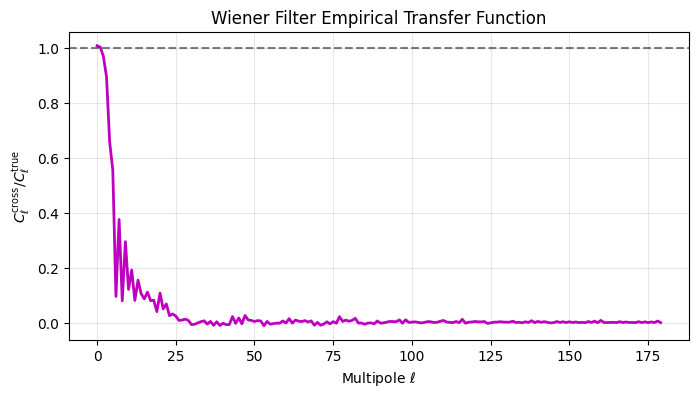

In [6]:
fig = msplt.plot_transfer_function(x_true, x_rec)
plt.show()

## Maps & Residuals (Equatorial)

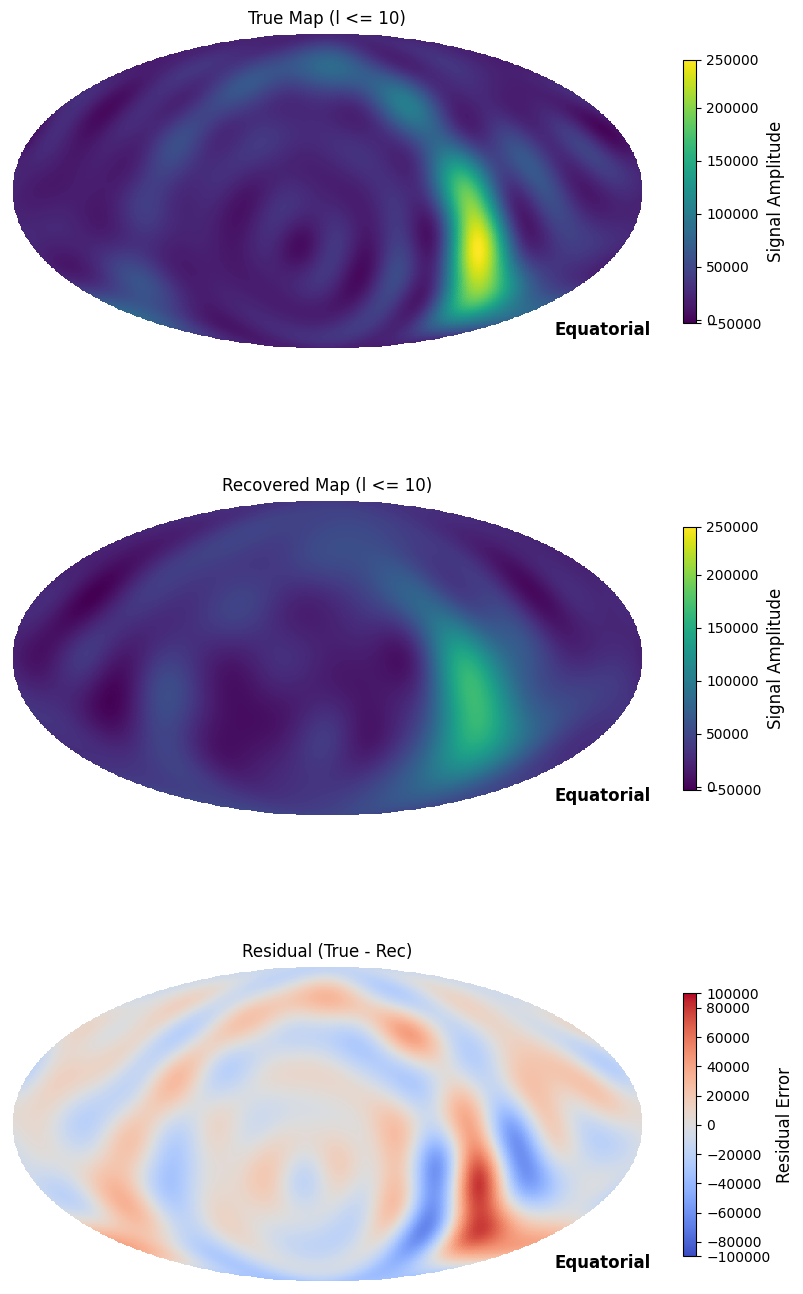

In [7]:
fig = msplt.plot_maps_and_residuals(
    x_true, x_rec, lmax, plot_lmax=10,
    nside=128, plot_galactic=False
)
plt.show()

## Maps & Residuals (Galactic)

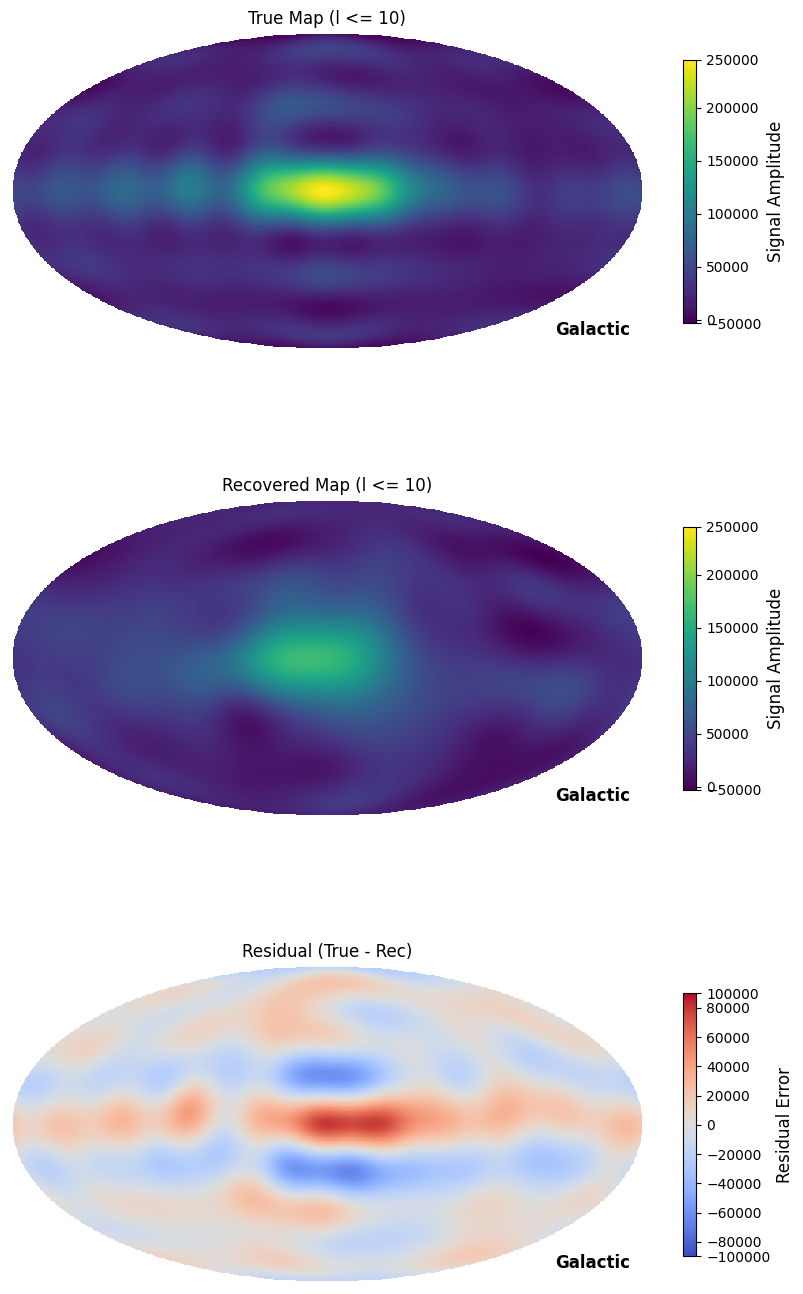

In [8]:
fig = msplt.plot_maps_and_residuals(
    x_true, x_rec, lmax, plot_lmax=10,
    nside=128, plot_galactic=True
)
plt.show()

## Posterior Uncertainty

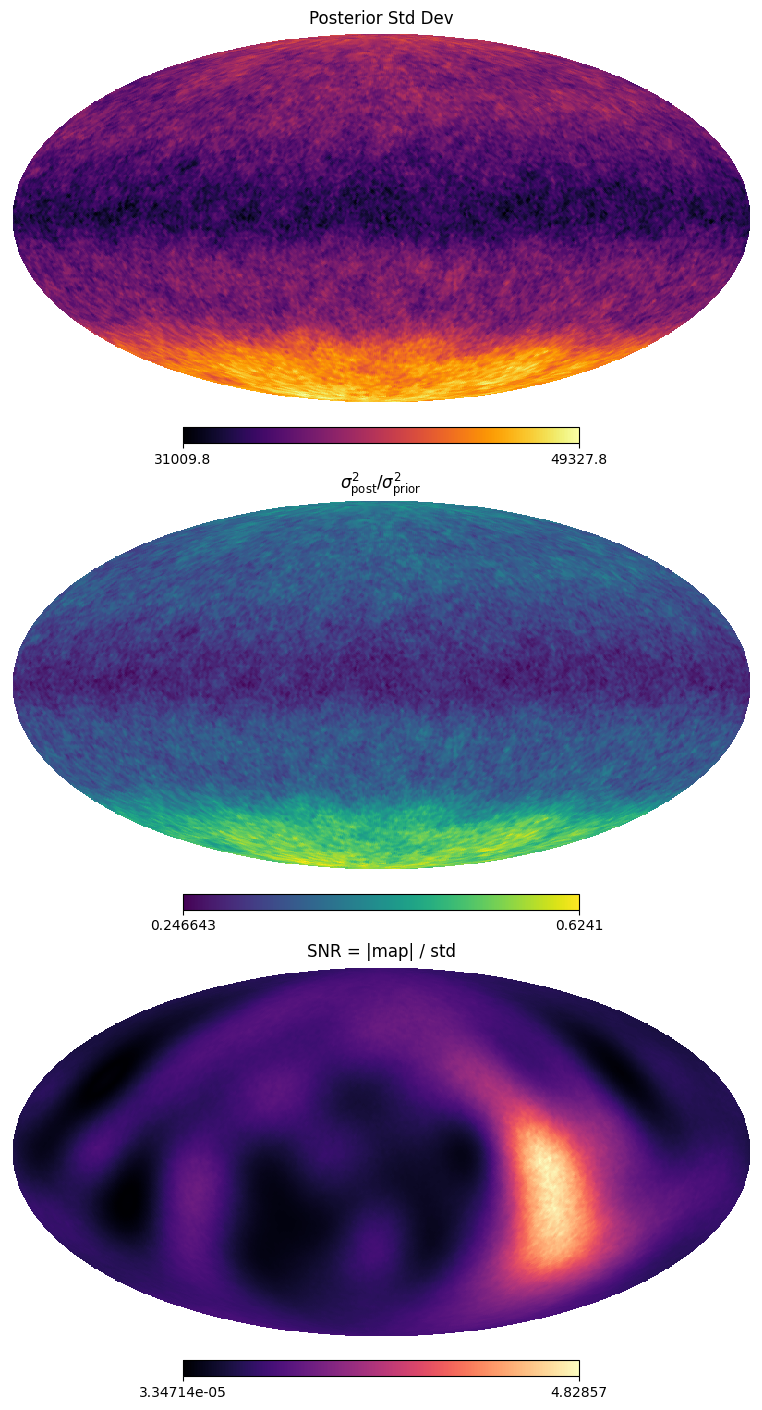

In [9]:
fl = np.ones(lmax + 1)
fl[11:] = 0.0
best_map = hp.alm2map(
    hp.almxfl(x_rec, fl), nside=128
)
fig = msplt.plot_posterior_maps(
    std_map, sigma2_prior, best_map, nside=128
)
plt.show()